In [28]:
# 导入必要的库
%matplotlib inline
import os
from brainnetwork import load_data, preprocess_data, preprocess_spike_data, rr_selection_class
from brainnetwork import classify_by_timepoints, FI_by_timepoints_v2, FI_by_neuron_count
from brainnetwork import construct_correlation_network, compute_network_metrics_by_class
from brainnetwork.visualization import *
# %% 可视化相关函数定义
from tifffile import imread 
import numpy as np
import pandas as pd
import scipy.stats as stats

In [29]:
base_dir = "D:\Data\Micedata\\"
data_paths = ["M21_1107", "M71_1024", "M73_1128", "M77_1031", "M77_1107", "M78_1017", "M79_1128", "M91_1017"]
idx = 7 # Change this index to select different datasets
data_path = base_dir + data_paths[idx] # 'M77_1031'
print(f"Processing data from: {data_path}")
save_dir = "../results/" + data_paths[idx] 

data_out_dir = os.path.join(save_dir, "data")
fig_out_dir = os.path.join(save_dir, "figures")

os.makedirs(data_out_dir, exist_ok=True)
os.makedirs(fig_out_dir, exist_ok=True)

Processing data from: D:\Data\Micedata\M91_1017


<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\GuiYun\AppData\Local\Temp\ipykernel_38700\4063873509.py:1: SyntaxWarning: invalid escape sequence '\D'
  base_dir = "D:\Data\Micedata\\"


In [30]:
neuron_data_flo, neuron_pos_flo, start_edges_flo, stimulus_data_flo = load_data(data_path, data_type='fluorescence')
segments_flo, labels_flo, neuron_pos_rr = preprocess_data(
    neuron_data_flo,
    neuron_pos_flo,
    start_edges_flo,
    stimulus_data_flo,
)

原始神经数据形状: (8401, 21918)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 336 个 RR 神经元
  - 类别 2 贡献了 312 个 RR 神经元
  - 类别 3 贡献了 382 个 RR 神经元
三类并集后共筛选出 578 个唯一 RR 神经元


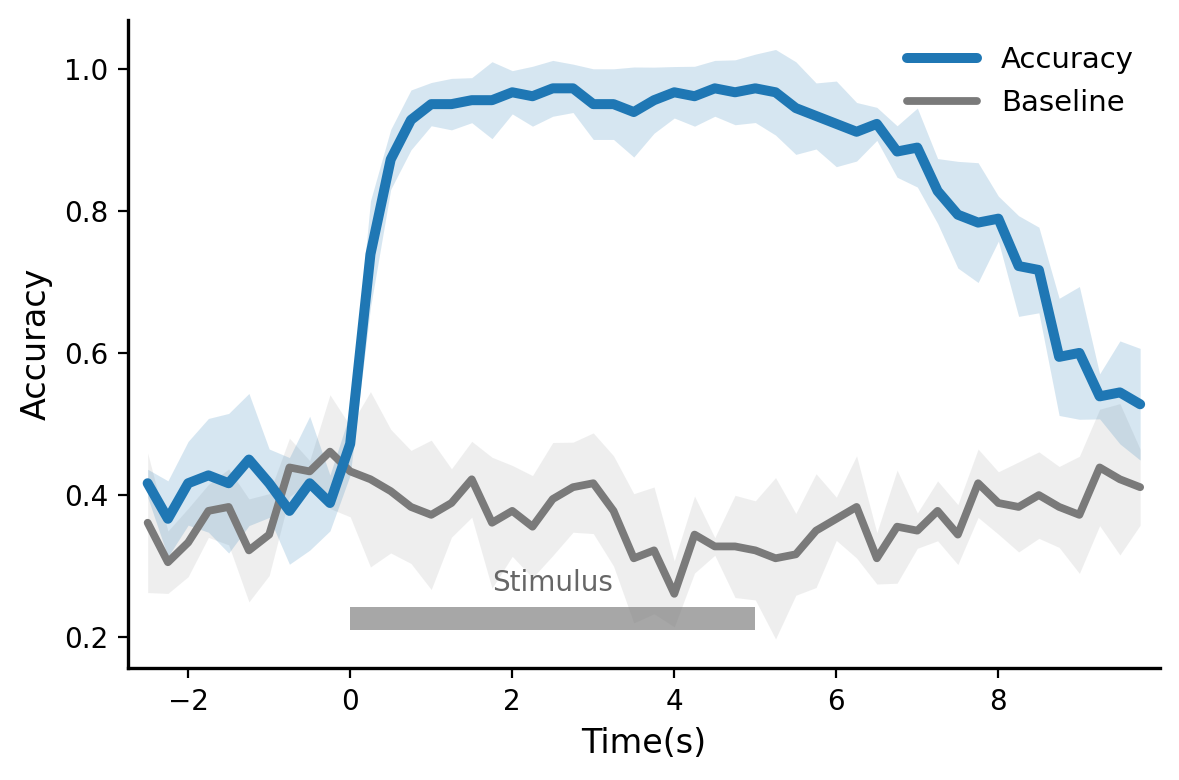

In [31]:
accuracies, time_points, accuracy_std, n_folds = classify_by_timepoints(segments_flo, labels_flo)

# 进行标签随机打乱的分类分析，作为基线比较
labels_shuffled = np.random.permutation(labels_flo)
accuracies_shu, time_points_shu, accuracy_std_shu, n_folds_shu = classify_by_timepoints(segments_flo, labels_shuffled)



plot_accuracy(time_points=time_points, accuracies=accuracies, baseline=accuracies_shu, accuracy_std=accuracy_std, baseline_std=accuracy_std_shu, save_path=os.path.join(fig_out_dir, "classification_accuracy.png"))